In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/processed/data_preprocessed.csv')
print(f"Shape: {df.shape}")
print(f"\nDistribusi Churn:\n{df['Churn'].value_counts()}")

Shape: (9364, 19)

Distribusi Churn:
Churn
1    4682
0    4682
Name: count, dtype: int64


In [3]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"\nDistribusi y_train:\n{y_train.value_counts()}")
print(f"\nDistribusi y_test:\n{y_test.value_counts()}")

X_train : (7491, 18)
X_test  : (1873, 18)

Distribusi y_train:
Churn
1    3746
0    3745
Name: count, dtype: int64

Distribusi y_test:
Churn
0    937
1    936
Name: count, dtype: int64


In [4]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred))
    print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
    
    # Confusion Matrix
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=axes[0]
    )
    axes[0].set_title(f'Confusion Matrix — {model_name}')
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[1].plot(fpr, tpr, label=f'AUC = {auc:.4f}')
    axes[1].plot([0,1], [0,1], 'k--')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'ROC Curve — {model_name}')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    return {
        'model': model_name,
        'auc': roc_auc_score(y_test, y_prob),
        'report': classification_report(y_test, y_pred, output_dict=True)
    }


  Logistic Regression
              precision    recall  f1-score   support

           0       0.78      0.71      0.74       937
           1       0.73      0.80      0.76       936

    accuracy                           0.75      1873
   macro avg       0.76      0.75      0.75      1873
weighted avg       0.76      0.75      0.75      1873

AUC-ROC: 0.8301


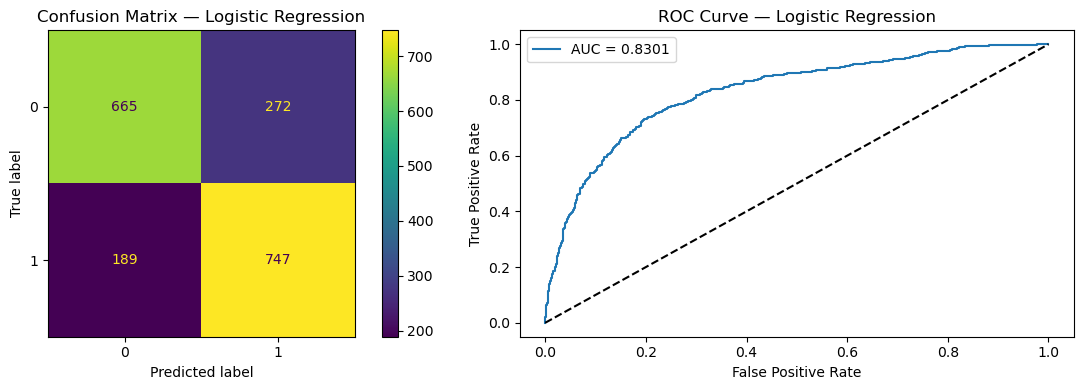

In [5]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

result_lr = evaluate_model(lr, X_test, y_test, "Logistic Regression")


  Random Forest
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       937
           1       0.98      1.00      0.99       936

    accuracy                           0.99      1873
   macro avg       0.99      0.99      0.99      1873
weighted avg       0.99      0.99      0.99      1873

AUC-ROC: 0.9993


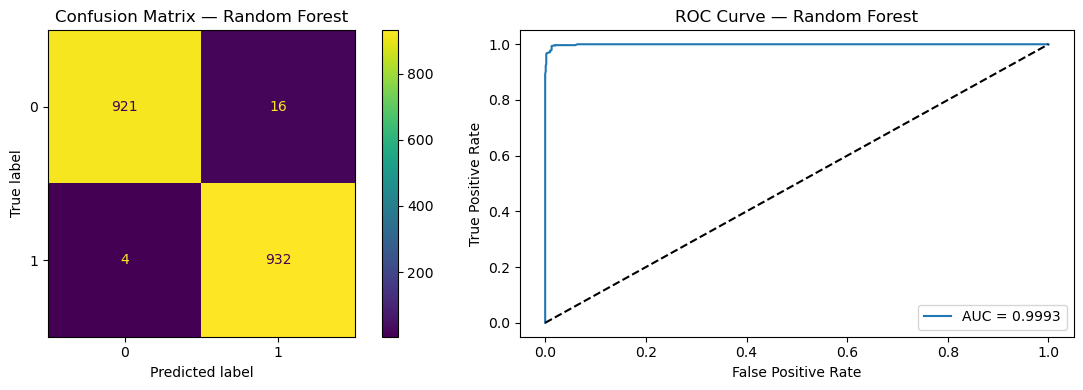

In [6]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

result_rf = evaluate_model(rf, X_test, y_test, "Random Forest")


  XGBoost
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       937
           1       0.99      0.99      0.99       936

    accuracy                           0.99      1873
   macro avg       0.99      0.99      0.99      1873
weighted avg       0.99      0.99      0.99      1873

AUC-ROC: 0.9984


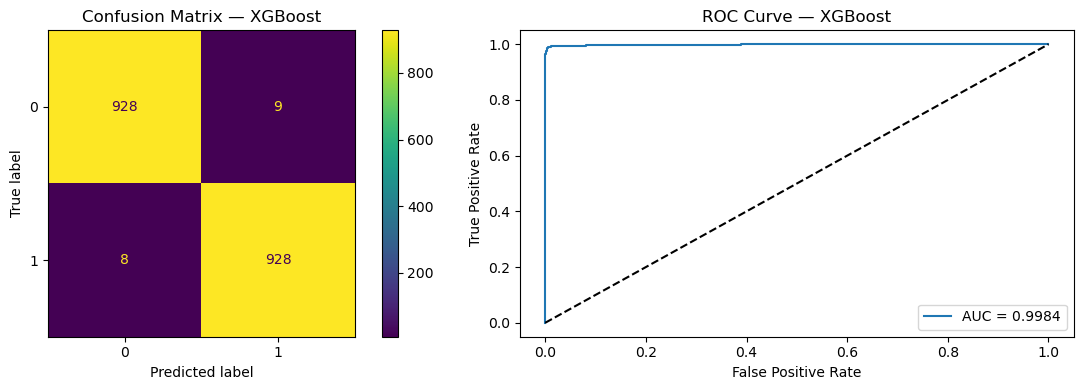

In [7]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

result_xgb = evaluate_model(xgb_model, X_test, y_test, "XGBoost")

              Model  AUC-ROC  Precision (Churn)  Recall (Churn)  F1 (Churn)  Accuracy
Logistic Regression   0.8301             0.7331          0.7981      0.7642    0.7539
      Random Forest   0.9993             0.9831          0.9957      0.9894    0.9893
            XGBoost   0.9984             0.9904          0.9915      0.9909    0.9909


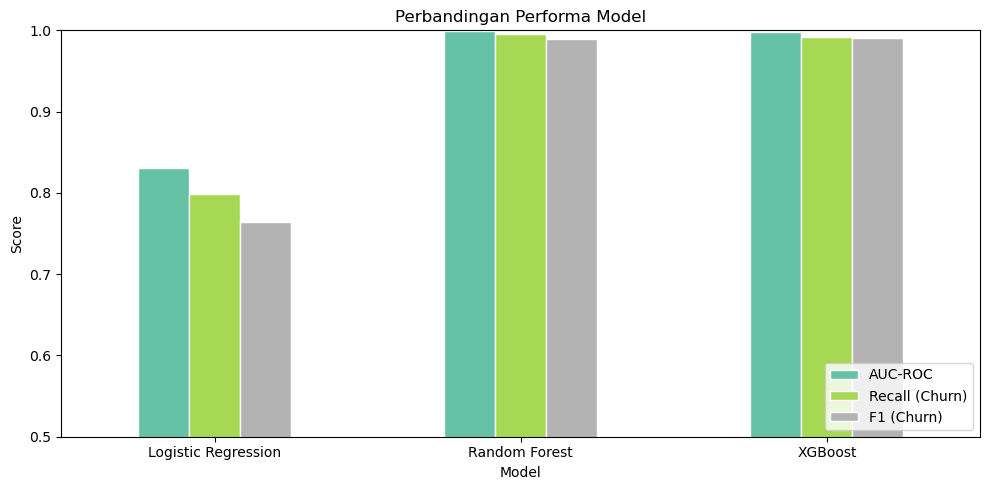

In [8]:
results = [result_lr, result_rf, result_xgb]

comparison = pd.DataFrame([{
    'Model': r['model'],
    'AUC-ROC': round(r['auc'], 4),
    'Precision (Churn)': round(r['report']['1']['precision'], 4),
    'Recall (Churn)': round(r['report']['1']['recall'], 4),
    'F1 (Churn)': round(r['report']['1']['f1-score'], 4),
    'Accuracy': round(r['report']['accuracy'], 4),
} for r in results])

print(comparison.to_string(index=False))

# Visualisasi perbandingan
comparison.set_index('Model')[['AUC-ROC', 'Recall (Churn)', 'F1 (Churn)']].plot(
    kind='bar', figsize=(10, 5), rot=0, colormap='Set2', edgecolor='white'
)
plt.title('Perbandingan Performa Model')
plt.ylabel('Score')
plt.ylim(0.5, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb_model
}

print("Cross Validation (5-Fold) — Recall Score")
print("=" * 45)

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='recall')
    print(f"{name:25s}: {scores.mean():.4f} (+/- {scores.std():.4f})")

Cross Validation (5-Fold) — Recall Score
Logistic Regression      : 0.7892 (+/- 0.0144)
Random Forest            : 0.9925 (+/- 0.0047)
XGBoost                  : 0.9944 (+/- 0.0040)


In [10]:
# Simpan XGBoost sebagai model utama (F1 sedikit lebih tinggi & lebih stabil)
joblib.dump(xgb_model, '../models/xgboost_churn.pkl')
joblib.dump(rf, '../models/random_forest_churn.pkl')

print("Model tersimpan!")
print("- models/xgboost_churn.pkl")
print("- models/random_forest_churn.pkl")

Model tersimpan!
- models/xgboost_churn.pkl
- models/random_forest_churn.pkl


In [11]:
print("=" * 50)
print("SUMMARY MODELING")
print("=" * 50)
print(f"""
✅ MODEL TERPILIH: XGBoost

📊 PERFORMA TEST SET
- Accuracy  : 99.09%
- Recall    : 99.15%
- Precision : 99.04%
- F1 Score  : 99.09%
- AUC-ROC   : 0.9984

🔄 CROSS VALIDATION (5-Fold)
- CV Recall : 0.9944 (+/- 0.0040)
- Konsisten di semua fold → tidak overfitting

💾 MODEL TERSIMPAN
- models/xgboost_churn.pkl
- models/random_forest_churn.pkl
""")

SUMMARY MODELING

✅ MODEL TERPILIH: XGBoost

📊 PERFORMA TEST SET
- Accuracy  : 99.09%
- Recall    : 99.15%
- Precision : 99.04%
- F1 Score  : 99.09%
- AUC-ROC   : 0.9984

🔄 CROSS VALIDATION (5-Fold)
- CV Recall : 0.9944 (+/- 0.0040)
- Konsisten di semua fold → tidak overfitting

💾 MODEL TERSIMPAN
- models/xgboost_churn.pkl
- models/random_forest_churn.pkl

